In [1]:
# Dependencies 

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from datetime import datetime
import os
import glob
from functools import reduce
from pyspark.sql import functions as F
from pyspark.sql.types import LongType
import requests

Matplotlib created a temporary cache directory at /scratch/asanchez9/job_49772451/matplotlib-6xwlwkww because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# SparkSession Configuration

# 16 cores, 128GB total memory — local[*] mode
# In local mode there are no separate executor processes — all task execution
# runs as threads within a single JVM. Executor config parameters have no effect
# and are omitted. Driver memory is set to 120GB to give the JVM nearly the
# full node allocation.
spark = SparkSession.builder \
    .appName("PushshiftRedditPreprocessing") \
    .master("local[*]") \
    .config("spark.driver.memory", "120g") \
    .config("spark.driver.maxResultSize", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.parquet.enableVectorizedReader", "true") \
    .config("spark.local.dir", '/expanse/lustre/scratch/asanchez9/temp_project/spark-tmp') \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")

Spark version: 3.5.0
Spark UI: http://exp-3-29.expanse.sdsc.edu:4040


## Milestone 4: Second Model Using PCA Dimensionality Reduction

For Milestone 4, we extend the Milestone 4 modeling pipeline by training a second model that includes an unsupervised dimensionality reduction step. The original Milestone 3 model used the full standardized feature vector to train XGBoost classifiers. Here, we instead apply Principal Component Analysis (PCA) to the standardized feature vector and train supervised classifiers on the reduced feature representation.

This approach satisfies the Milestone 4 requirement of using dimensionality reduction before additional modeling and analysis. PCA is fit only on the training split to avoid information leakage, then the learned transformation is applied to the validation and test splits

### Reloading Persisted Train, Validation, and Test Splits

The train, validation, and test datasets were already created in Milestone 3 pipeline and saved to disk. To avoid rerunning the full raw-data processing and feature-engineering pipeline, we reload the persisted splits directly from `data/processed/`.

These splits preserve the original time-based split strategy:

- Training set: posts before January 1, 2017
- Validation set: posts from 2017
- Test set: posts from 2018 onward

Using the same splits allows the PCA-based model to be compared fairly against the Milestone 3 baseline models.

In [3]:
# Reloading train val and test dfs
# Note: This is checkpoint for model fitting; data load is done in persist cell
#       to validate counts

TRAIN_DIR = "../data/processed/train"
VAL_DIR   = "../data/processed/val"
TEST_DIR  = "../data/processed/test"


print("\nReloading splits from disk...")
train_df = spark.read.parquet(TRAIN_DIR)
val_df   = spark.read.parquet(VAL_DIR)
test_df  = spark.read.parquet(TEST_DIR)

print(f"Train rows: {train_df.count():,}")
print(f"Val rows:   {val_df.count():,}")
print(f"Test rows:  {test_df.count():,}")


Reloading splits from disk...
Train rows: 276,442,594
Val rows:   114,089,205
Test rows:  144,949,019


### PCA Dimensionality Reduction

The Milestone 3 pipeline already produced a standardized feature vector names `features`. This vector was created from the original engineered feature vector `features_raw` using `StandardScaler`, fit on the training set only.

For the second model, we apply PCA to standardized `features` column. PCA is an unsupervised dimensionality reduction technique that projects the original feature space into a smaller set of orthogonal principal components. These components capture directions of maximum variance in the data.

For this experiment, we use `k = 8` principal components. This reduces the dimensionality of the feature vector while retaining a majority of the variance in the standardized feature space.

In [4]:
from pyspark.ml.feature import StandardScaler, PCA
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

In [5]:
#--------- Fitting the PCA Model ---------

K = 8

pca = PCA(
    k=K,
    inputCol="features",
    outputCol="features_pca"
)

pca_model = pca.fit(train_df)

train_pca = pca_model.transform(train_df)
val_pca = pca_model.transform(val_df)
test_pca = pca_model.transform(test_df)

print("PCA complete.")
train_pca.select("features_pca").show(3, truncate=80)

PCA complete.
+--------------------------------------------------------------------------------+
|                                                                    features_pca|
+--------------------------------------------------------------------------------+
|[-2.248075760586396,-1.0108508113557189,-1.8743470034369212,-2.38318922433573...|
|[-1.2716108696596324,-2.4434141800121254,-0.025118866782646687,-0.87611516062...|
|[-2.244948202486038,-1.1495308667208963,-0.633291556579845,0.7235427071529736...|
+--------------------------------------------------------------------------------+
only showing top 3 rows



### PCA Explained Variance

The 8-component PCA model preserved approximately **59.8%** of the cumulative variance in the standardied feature space.

This means that the reduced representation keeps a majority of the overall feature variation while discarding about 40.2% of the variance. Because PCA is unsupervised, the retained variance is not guaranteed to be the most predictive variance for the engagement classification task. However, the explained variance provides a useful way to understand how much information is preserved after dimensionality reduction.

The cumulative explained variance table shows how much additional variance is captured by each principal component.

In [6]:
#------ Display Variance ------

explained = pca_model.explainedVariance.toArray()
cumulative = np.cumsum(explained)

pca_variance_df = pd.DataFrame({
    "principal_component": list(range(1, len(explained) + 1)),
    "explained_variance": explained,
    "cumulative_explained_variance": cumulative
})

pca_variance_df

,principal_component,explained_variance,cumulative_explained_variance
0,1,0.117563,0.117563
1,2,0.088383,0.205947
2,3,0.075738,0.281685
3,4,0.068655,0.350340
4,5,0.065428,0.415769
5,6,0.063325,0.479093
6,7,0.059761,0.538855
7,8,0.059295,0.598149


### PCA + Logistic Regression Model

The first supervised model trained on the PCA-reduced features is Logistic Regression

In [7]:
#-------- Fitting PCA to Logistic Regression Classifier -------

LABEL_COL = "label_4class_idx"

lr_pca = LogisticRegression(
    labelCol=LABEL_COL,
    featuresCol="features_pca",
    maxIter=50,
    regParam=0.01,
    elasticNetParam=0.0
)

lr_pca_model = lr_pca.fit(train_pca)

train_pred = lr_pca_model.transform(train_pca)
val_pred = lr_pca_model.transform(val_pca)
test_pred = lr_pca_model.transform(test_pca)

print("PCA Logistic Regression model trained.")

PCA Logistic Regression model trained.


### PCA + Logistic Regression Model

The first supervised model trained on the PCA-reduced features is Logistic Regression. This model provides a simpler linear baseline for evaluating whether the reduced PCA representation still contains enough information to depsarate the four engagement classes.

This model uses:

- Input features: `features_pca`
- Label column: `label_4class_idx`
- Number of PCA components: `k=8`

Logistic Regression is useful here because it is relatively interpretable and efficient compared with more complexnonlinear models. If performance is weak, that may indicate either the PCA representation remnoved useful predictive information or that the class boundaries are not well modeled by a linear classifier.

### Evaluation Strategy

Because the dataset is extremely large, full evaluation over every split can be computationally expensive. To reduce the chance of Spark executor failure, we evaluate the full validation and test sets, but only evaluate 1% sample of the training predictions.

This still supports the fitting analysis required for Milestone 4:

- Validation and test performance measure generalization.
- The sampled training performance gives an approximate view of training fit.
- Comparing training, validation, and test metrics helps identify underfitting or overfitting.

The main reported metrics are weighted F1 score and accuracy.

In [8]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def evaluate_pca_model(preds, label_col="label_4class_idx", split_name=""):
    evaluator = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction"
    )

    metrics = {}
    for metric in ("f1", "accuracy", "weightedPrecision", "weightedRecall"):
        evaluator.setMetricName(metric)
        metrics[metric] = evaluator.evaluate(preds)

    print(f"\n--- {split_name} ---")
    print(f"Weighted F1:   {metrics['f1']:.4f}")
    print(f"Accuracy:      {metrics['accuracy']:.4f}")
    print(f"W-Precision:   {metrics['weightedPrecision']:.4f}")
    print(f"W-Recall:      {metrics['weightedRecall']:.4f}")

    return metrics

In [9]:
#----- Evaluation of the Model -------

lr_results = {
    "model": "PCA + LogisticRegression",
    "task": "4-class classification",
    "k": K,
    "cumulative_explained_variance": float(cumulative[-1])
}

lr_results["val"] = evaluate_pca_model(val_pred, split_name="Val")
lr_results["test"] = evaluate_pca_model(test_pred, split_name="Test")

train_sample_pred = train_pred.sample(False, 0.01, seed=42)
lr_results["train_sample_1pct"] = evaluate_pca_model(
    train_sample_pred,
    split_name="Train Sample 1%"
)

lr_results


--- Val ---
Weighted F1:   0.4295
Accuracy:      0.5175
W-Precision:   0.4918
W-Recall:      0.5175

--- Test ---
Weighted F1:   0.4211
Accuracy:      0.5106
W-Precision:   0.4839
W-Recall:      0.5106

--- Train Sample 1% ---
Weighted F1:   0.3927
Accuracy:      0.5031
W-Precision:   0.4020
W-Recall:      0.5031


{'model': 'PCA + LogisticRegression',
 'task': '4-class classification',
 'k': 8,
 'cumulative_explained_variance': 0.5981494442065166,
 'val': {'f1': 0.42946949170391924,
  'accuracy': 0.5174909492970873,
  'weightedPrecision': 0.49179897136579853,
  'weightedRecall': 0.5174909492970873},
 'test': {'f1': 0.42105575385022587,
  'accuracy': 0.5106312999607124,
  'weightedPrecision': 0.48394867212555315,
  'weightedRecall': 0.5106312999607124},
 'train_sample_1pct': {'f1': 0.39273522168274233,
  'accuracy': 0.5031289958685525,
  'weightedPrecision': 0.4019973244120193,
  'weightedRecall': 0.5031289958685525}}

### PCA + Logistic Regression Results

The PCA + Logistic Regression model achieved the following performance:

| Split | F1 Score | Accuracy |
|---|---:|---:|
| Train Sample 1% | 0.3931 | 0.5034 |
| Validation | 0.4295 | 0.5175 |
| Test | 0.4211 | 0.5106 |

The validation and test scores are very close, suggesting that the model does not show strong evidence of overfitting. However, the overall F1 scores are relatively low compared with the Milestone 3 XGBoost baseline. This suggests that the PCA + Logstic Regression model is likely underfitting the engagement classification task.

One reason for this is that PCA is unsupervised: it preserves directions of high variance, but those directions are not necessarily the most useful for predicting engagement labels. Additionally, Logistic Regression is a linear model, so it may not capture nonlinear relationships between the PCA components and the engagement classes.

### PCA + Random Forest Model

After evaluating PCA + Logistic Regression, we also train a Random Forest classifier on the PCA-reduced feature space. Logistic Regression provides a linear baseline, while Random Forest can model nonlinear relationships between the PCA components and the engagement classes.

This helps determine whether the PCA representation still contains useful predictive structure that a nonlinear classifier can exploit.

The Random Forest model uses:

- Input features: `features_pca`
- Label column: `label_4class_idx`
- Number of PCA components: `k = 8`
- Number of trees: 50
- Maximum tree depth: 8

In [10]:
#----- Trying PCA + RandomForests to see if I can get a better accuracy  ------

rf_pca = RandomForestClassifier(
    labelCol="label_4class_idx",
    featuresCol="features_pca",
    numTrees=50,
    maxDepth=8,
    seed=42
)

rf_pca_model = rf_pca.fit(train_pca)

val_pred_rf = rf_pca_model.transform(val_pca)
test_pred_rf = rf_pca_model.transform(test_pca)

print("PCA RandomForests model trained.")

PCA RandomForests model trained.


### PCA + Random Forest Evaluation

The PCA + Random Forest model is evaluated using the same strategy as the Logistic Regression model. We evaluate the full validation and test sets, and use a 1% training sample for fitting analysis.

This keeps the evaluation consistent while avoiding repeated full scans of the very large training set.

In [11]:
# ----- Evaluation of PCA + Random Forest Model -----

rf_results = {
    "model": "PCA + RandomForest",
    "task": "4-class classification",
    "k": K,
    "cumulative_explained_variance": float(cumulative[-1])
}

print("Evaluating validation set...")
rf_results["val"] = evaluate_pca_model(
    val_pred_rf,
    label_col=LABEL_COL,
    split_name="Validation"
)

print("Evaluating test set...")
rf_results["test"] = evaluate_pca_model(
    test_pred_rf,
    label_col=LABEL_COL,
    split_name="Test"
)

print("Evaluating 1% training sample...")
train_sample_pred_rf = train_pca.sample(False, 0.01, seed=42)
train_sample_pred_rf = rf_pca_model.transform(train_sample_pred_rf)

rf_results["train_sample_1pct"] = evaluate_pca_model(
    train_sample_pred_rf,
    label_col=LABEL_COL,
    split_name="Train Sample 1%"
)

rf_results

Evaluating validation set...

--- Validation ---
Weighted F1:   0.5202
Accuracy:      0.5866
W-Precision:   0.5320
W-Recall:      0.5866
Evaluating test set...

--- Test ---
Weighted F1:   0.5070
Accuracy:      0.5803
W-Precision:   0.5193
W-Recall:      0.5803
Evaluating 1% training sample...

--- Train Sample 1% ---
Weighted F1:   0.4718
Accuracy:      0.5520
W-Precision:   0.4841
W-Recall:      0.5520


{'model': 'PCA + RandomForest',
 'task': '4-class classification',
 'k': 8,
 'cumulative_explained_variance': 0.5981494442065166,
 'val': {'f1': 0.5201812860512536,
  'accuracy': 0.5866499551819999,
  'weightedPrecision': 0.532044865779981,
  'weightedRecall': 0.5866499551819999},
 'test': {'f1': 0.5070203860596572,
  'accuracy': 0.5802760141481192,
  'weightedPrecision': 0.5192656917541041,
  'weightedRecall': 0.5802760141481192},
 'train_sample_1pct': {'f1': 0.47183341277105845,
  'accuracy': 0.5519736241903275,
  'weightedPrecision': 0.484058882984277,
  'weightedRecall': 0.5519736241903275}}

In [12]:
lr_summary = {
    "model": lr_results["model"],
    "k": lr_results["k"],
    "cumulative_explained_variance": lr_results["cumulative_explained_variance"],
    "train_f1_sample_1pct": lr_results["train_sample_1pct"]["f1"],
    "train_accuracy_sample_1pct": lr_results["train_sample_1pct"]["accuracy"],
    "val_f1": lr_results["val"]["f1"],
    "val_accuracy": lr_results["val"]["accuracy"],
    "test_f1": lr_results["test"]["f1"],
    "test_accuracy": lr_results["test"]["accuracy"],
}

rf_summary = {
    "model": rf_results["model"],
    "k": rf_results["k"],
    "cumulative_explained_variance": rf_results["cumulative_explained_variance"],
    "train_f1_sample_1pct": rf_results["train_sample_1pct"]["f1"],
    "train_accuracy_sample_1pct": rf_results["train_sample_1pct"]["accuracy"],
    "val_f1": rf_results["val"]["f1"],
    "val_accuracy": rf_results["val"]["accuracy"],
    "test_f1": rf_results["test"]["f1"],
    "test_accuracy": rf_results["test"]["accuracy"],
}

comparison_df = pd.DataFrame([lr_summary, rf_summary])
comparison_df

,model,k,cumulative_explained_variance,train_f1_sample_1pct,train_accuracy_sample_1pct,val_f1,val_accuracy,test_f1,test_accuracy
0,PCA + LogisticRegression,8,0.598149,0.392735,0.503129,0.429469,0.517491,0.421056,0.510631
1,PCA + RandomForest,8,0.598149,0.471833,0.551974,0.520181,0.586650,0.507020,0.580276


In [13]:
import os
import json

os.makedirs("../outputs", exist_ok=True)

comparison_df.to_csv("../outputs/pca_model_comparison.csv", index=False)

with open("../outputs/pca_logistic_regression_results.json", "w") as f:
    json.dump(lr_results, f, indent=2)

with open("../outputs/pca_random_forest_results.json", "w") as f:
    json.dump(rf_results, f, indent=2)

pca_variance_df.to_csv("../outputs/pca_explained_variance.csv", index=False)

print("Saved PCA model results and explained variance outputs.")

Saved PCA model results and explained variance outputs.


### Comparison of PCA-Based Models

The table above compares the supervised models trained on the PCA-reduced feature space. Both models use the same PCA representation, so differences in performance are due to the classifier rather than the dimensionality reduction step.

The PCA + Logistic Regression model achieved a validation F1 score of **0.4295** and a test F1 score of **0.4211**. The validation and test scores are close, suggesting that the model does not show strong evidence of overfitting. However, the overall F1 score is relatively low, suggesting underfitting.

The PCA + Random Forest model achieved a validation F1 score of **0.5202** and a test F1 score of **0.5070**. Compared with Logistic Regression, Random Forest performed better on both validation and test F1. This suggests that the PCA-reduced features still contain useful predictive structure, but that the relationship between the principal components and engagement labels is at least partly nonlinear.

Overall, the PCA-based models performed below the Milestone 3 XGBoost baseline, indicating that compressing the standardized feature vector into 8 principal components likely removed useful predictive information for the 4-class engagement task.

### Fitting Analysis

The PCA + Logistic Regression model appears to be underfitting. The training-sample, validation, and test F1 scores are all relatively close, but the overall performance is modest. This means the model is not memorizing the training data, but it also does not capture enough structure to strongly separate the four engagement classes.

This likely happens for two reasons. First, PCA is unsupervised and preserves directions of high variance rather than directions that best separate the class labels. Second, Logistic Regression is a linear classifier, so it may not capture nonlinear relationships between the reduced PCA features and engagement outcomes.

The PCA + Random Forest model improved over Logistic Regression, with validation F1 increasing from **0.4295** to **0.5202** and test F1 increasing from **0.4211** to **0.5070**. This suggests that the PCA features still contain useful predictive structure, but that the relationship between the reduced features and engagement classes is at least partly nonlinear.

Even with this improvement, the PCA-based models still performed below the full-feature Milestone 3 XGBoost baseline. This suggests that reducing the standardized feature vector to 8 principal components likely removed some predictive information that was useful for the 4-class engagement task.

### Milestone 4 Summary

For Milestone 4, we implemented a second modeling approach using PCA for unsupervised dimensionality reduction. PCA was fit on the training split only and then applied to the validation and test splits to avoid leakage.

Using 8 principal components, PCA preserved approximately **59.8%** of the cumulative variance in the standardized feature space. We then trained supervised classifiers on the PCA-transformed features, including Logistic Regression and Random Forest.

The PCA + Logistic Regression model achieved a validation F1 score of **0.4295** and a test F1 score of **0.4211**. The PCA + Random Forest model performed better, achieving a validation F1 score of **0.5202** and a test F1 score of **0.5070**. This indicates that a nonlinear classifier was better able to use the PCA-reduced feature representation.

However, both PCA-based models performed below the Milestone 3 XGBoost baseline. Overall, PCA provided a useful dimensionality reduction comparison model, but the results suggest that the full engineered feature set is more effective for Reddit engagement classification than the compressed 8-component PCA representation.

### PCA Model Comparison Plots

The following plots summarize the PCA model results. The explained variance plot shows how much variance was retained by the 8-component PCA representation. The F1 and accuracy plots compare Logistic Regression and Random Forest on the PCA-reduced feature space. The fitting-analysis plot compares training-sample, validation, and test F1 scores to assess underfitting or overfitting.

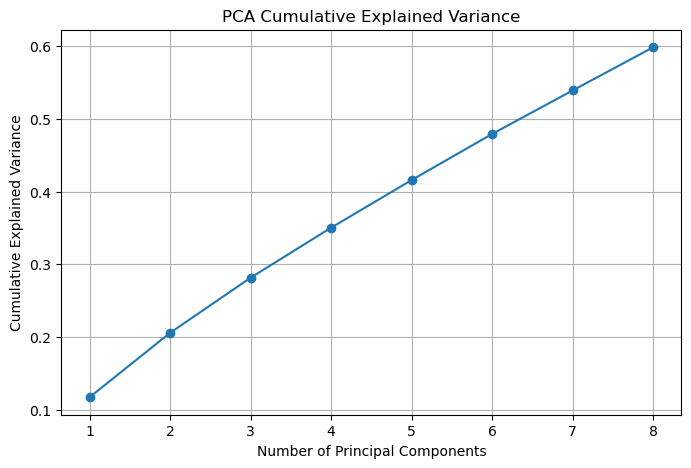

In [14]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(
    pca_variance_df["principal_component"],
    pca_variance_df["cumulative_explained_variance"],
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)

plt.savefig(
    "../outputs/figures/pca_cumulative_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

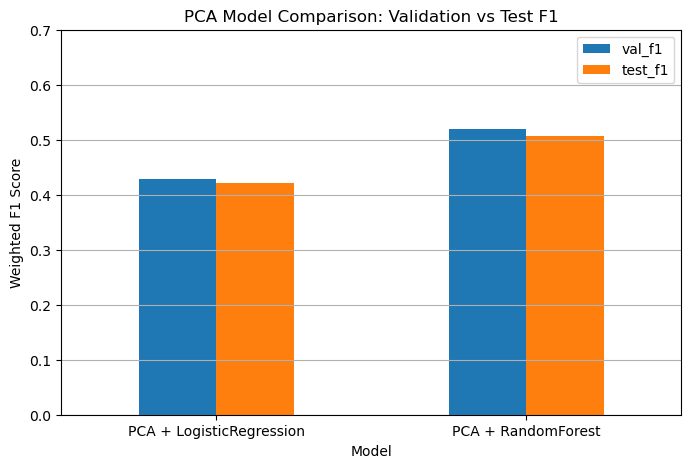

In [15]:
plot_df = comparison_df[["model", "val_f1", "test_f1"]].copy()
plot_df = plot_df.set_index("model")

ax = plot_df.plot(kind="bar", figsize=(8, 5))

plt.ylabel("Weighted F1 Score")
plt.xlabel("Model")
plt.title("PCA Model Comparison: Validation vs Test F1")
plt.xticks(rotation=0)
plt.ylim(0, 0.7)
plt.grid(axis="y")

plt.savefig(
    "../outputs/figures/pca_model_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

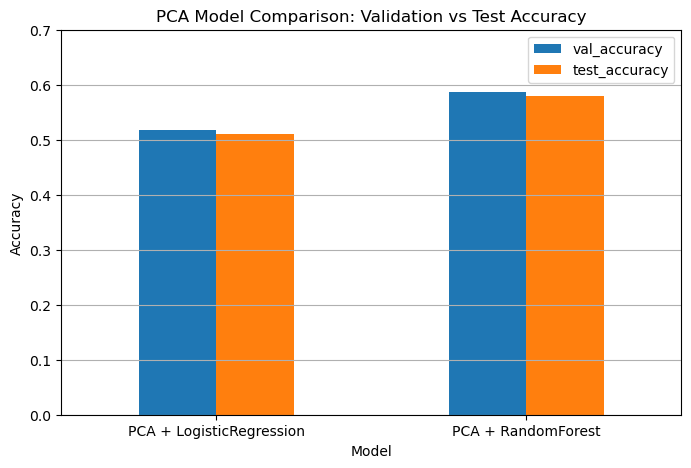

In [16]:
plot_df = comparison_df[["model", "val_accuracy", "test_accuracy"]].copy()
plot_df = plot_df.set_index("model")

ax = plot_df.plot(kind="bar", figsize=(8, 5))

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("PCA Model Comparison: Validation vs Test Accuracy")
plt.xticks(rotation=0)
plt.ylim(0, 0.7)
plt.grid(axis="y")

plt.savefig(
    "../outputs/figures/pca_model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

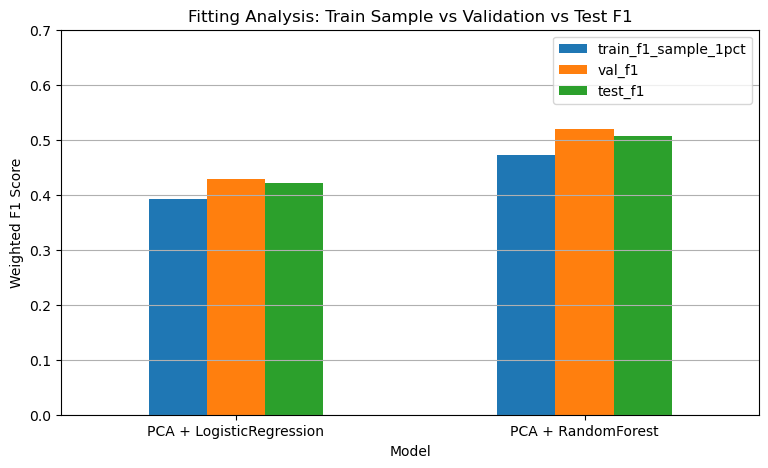

In [17]:
fit_df = comparison_df[
    ["model", "train_f1_sample_1pct", "val_f1", "test_f1"]
].copy()

fit_df = fit_df.set_index("model")

ax = fit_df.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Weighted F1 Score")
plt.xlabel("Model")
plt.title("Fitting Analysis: Train Sample vs Validation vs Test F1")
plt.xticks(rotation=0)
plt.ylim(0, 0.7)
plt.grid(axis="y")

plt.savefig(
    "../outputs/figures/pca_fitting_analysis_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Plot Interpretation

The cumulative explained variance plot shows that 8 principal components preserve approximately 59.8% of the variance in the standardized feature space.

The model comparison plots show that PCA + Random Forest outperformed PCA + Logistic Regression on both validation and test performance. This indicates that the PCA-reduced features still contain useful predictive signal, but the relationship between those components and engagement labels is not purely linear.

The fitting-analysis plot shows that train-sample, validation, and test F1 scores are relatively close for both models. This suggests that the PCA-based models are not strongly overfitting. Instead, the lower overall scores compared with the Milestone 3 XGBoost baseline suggest underfitting or information loss from dimensionality reduction.